## Instructions

**Purpose**
The purpose of this assignment is to demonstrate your understanding of optimal estimation.

**Task**
The notebook contains a series of questions and tasks that you will answer probability rules, calculation, or both. Each problem will specify the required method(s) of solution.

You will insert text and code cells to answer each question. The number of text and code cells you include for each question will depend on the question and how you answer it; there is no required number of cells, but you *must* include text to describe your answers.

I will use `Restart and run all` to run your code. Therefore, you should not include code that does not work in the middle of the notebook. If you are unable to answer a question and want to show your attempted solution, include the non-working code at the end of the notebook.

**Criteria**

The problems will be graded for both accuracy and clarity of the presentation.
A solution will receive full credit only when:
1. The solution is correct.
2. Text is included to describe the work.
3. Answers are given first in terms of probabilities of events before using numerical values.
4. All steps in the problem solving process are shown and probability rules used are justified.
5. If code is used, the code is clearly understandable through appropriate variable names and comments.


## Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy import stats, special
import seaborn as sns
sns.set_style("whitegrid")

## Introduction

This homework will involve using maximum likelihood and minimum mean square estimation to describe
the CO$_2$ emission distribution from 2018.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/brian-fischer/DATA-5100/main/CO2EmissionsProcessed1960to2018.csv')

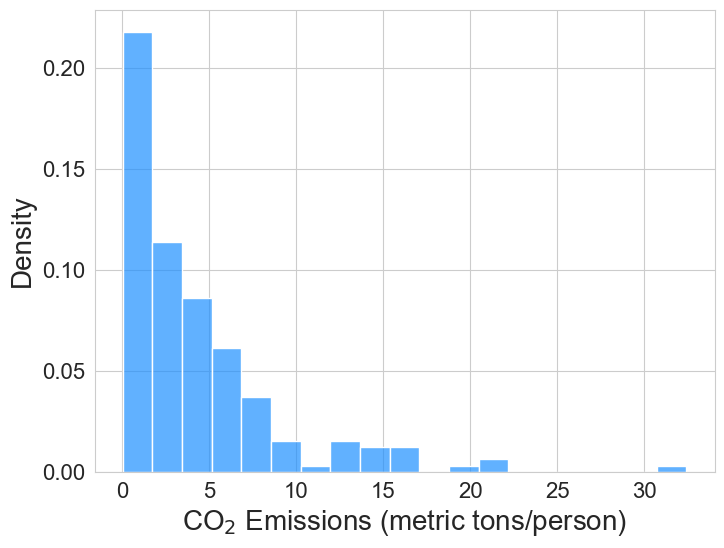

In [3]:
plt.figure(figsize = (8,6))
sns.histplot(data = df, x = '2018', stat = 'density', color = 'dodgerblue', alpha = 0.7)

#Label the axes
plt.ylabel('Density',fontsize = 20)
plt.xlabel('CO$_2$ Emissions (metric tons/person)',fontsize = 20)

#Set sizes of tick labels
plt.tick_params(labelsize = 16)

plt.show()

What exponential density best describes the data?

Use maximum likelihood estimation (MLE) to estimate the parameter $\lambda$ in the exponential distribution that best describes the data.



Compute the MLE estimate of the scale parameter, holding the location parameter fixed at 0.

In [4]:
loc, scale_mle = stats.expon.fit(df['2018'].dropna(), floc = 0)

print(loc, scale_mle)

0.0 4.189222603497382


The scale parameter is the standard deviation, so the maximum likelihood estimate the parameter $\lambda$ is

In [5]:
1 / scale_mle

0.23870777341007082

Create an exponential distribution object with the MLE parameter.

In [6]:
X = stats.expon(loc = loc, scale = scale_mle)

Compare the data distribution with the best fitting exponential pdf.

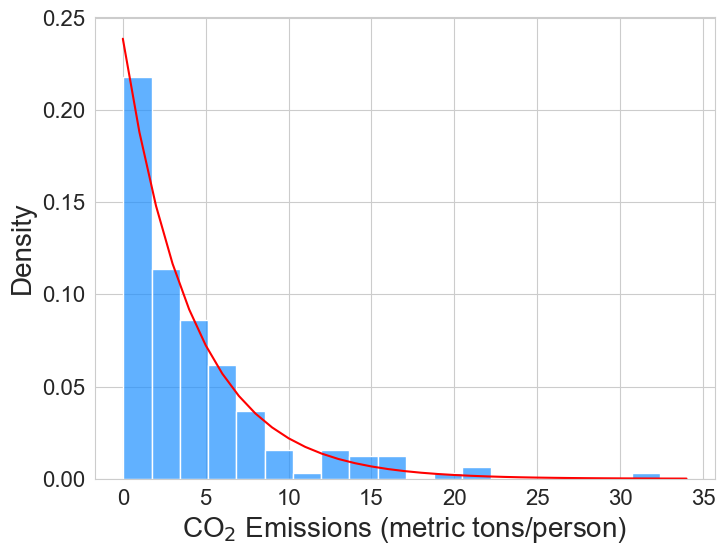

In [7]:
plt.figure(figsize = (8,6))
sns.histplot(data = df, x = '2018', stat = 'density', color = 'dodgerblue', alpha = 0.7)

#Label the axes
plt.ylabel('Density',fontsize = 20)
plt.xlabel('CO$_2$ Emissions (metric tons/person)',fontsize = 20)

#Set sizes of tick labels
plt.tick_params(labelsize = 16)

#Plot the exponential pdf
x_p = np.arange(0,35)
plt.plot(x_p, X.pdf(x_p),'r');

## Problem 1: 10 points

1. Derive mathematically the form for the maximum likelihood estimate of the parameter $\lambda$ in the exponential distribution that best describes the data given the $n$ observations $x_1, x_2, \ldots, x_n$ of CO$_2$ measurements.

2. Compute the the maximum likelihood estimate of the parameter $\lambda$ in the exponential distribution that best describes the data based on the formula you derive in part 1.

### Solution

$x_1, x_2,...,x_n ~ i.i.d, Exp(\lambda)$

$f(x|\lambda) = \lambda e^{-\lambda x}$

Goal: Estimate $\lambda$ based on observations $x_1, x_2,...,x_n ~ i.i.d, Exp(\lambda)$

Maximum Likelihood Estimator: $P(x_1, x_2,...,x_n|\lambda)$

$L(\lambda) = P(x_1, x_2,...,x_n|\lambda)$

$ = P(x_1|\lambda)P(x_2|\lambda)...P(x_n|\lambda)$

$ =  \lambda e^{-\lambda x_1}*\lambda e^{-\lambda x_2}...\lambda e^{-\lambda x_n}$

$ = \prod_{i=1}^{n} \lambda^n e^{-\lambda(x_1)+(x_2)+...+(x_n)}$

$ = \lambda^n e^{-\lambda\sum x_i}$

This is hard to dervie on its own, s owe can take the log of it in the statement below here:

$ l(\lambda) = logL(\lambda) = nlog(\lambda) - \lambda\sum x_i$

Derivative:

$\frac{d(\lambda)}{d\lambda} = \frac{n}{\lambda} - \sum x_i$

Second Derivative:

$\frac{d^2(\lambda)}{d\lambda} = - \frac{1}{\lambda^2}, \lambda \neq 0$

^The statement above represents a maximum since the determinant is negative.

$\frac{n}{\lambda} - \sum x_i = 0$

$\lambda\text{MLE} = \frac{\sum x_i}{n} = \bar{x} = \text{sample mean}$

So for the case of an exponential distribution, $\lambda_\text{MLE} = \frac{1}{\bar{x}}$

The sample mean of the distribution is the same as our MLE in this case.

In [19]:
1 / np.mean(df['2018'].dropna())

np.float64(0.23870777341007082)

## Problem 2: 10 points

Now suppose that the parameter $\lambda$ has an exponential prior distribution with probability density function

$$f_{\lambda}(\lambda) = \alpha e^{-\alpha \lambda}, \lambda \geq 0$$

with mean $\frac{1}{\alpha}$

Derive a formula for the minimum mean square estimate of $\lambda$ given the $n$ observations $x_1, x_2, \ldots, x_n$ of CO$_2$ measurements.


### Solution

For this problem, we will start with the prior distribution and then proceed to the MMSE after obtaining our prior formula.

Given that this problem states that we are using an exponential prior distribution, we know that the shape $\alpha = 1$, but that $\beta$ is still a variable term.

We can re-write our gamma prior distribution formula but with $shape = 1$ below:

$\lambda^n * e^{-\lambda\sum x_i} * \alpha^{1-1} e^{-\alpha \lambda}$

$\propto \lambda^n * e^{-\lambda\sum x_i} * 1*e^{-\alpha\lambda}$

The alpha values cancel out so we are left with:

$ \propto \lambda^n * e^{-\lambda\sum x_i} * 1*e^{-\alpha\lambda}$

$\propto \lambda^n * e^{-\lambda\sum x_i} * e^{-\alpha\lambda}$

Which ultimately simplifies to:

$ = \lambda^n * e^{-\lambda\sum x_i -\alpha\lambda} $

MMSE: 

$ \frac{n}{\alpha + \sum x_i}$